In [3]:
!pip install streamlit

In [10]:
import os
print(os.getcwd())

C:\Users\Yunju


In [19]:
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.leigod', '.matplotlib', '.spyder-py3', '.streamlit', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'esg_chart.png', 'Favorites', 'Links', 'Local Settings', 'MSCI_ESG评级分布.csv', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TM.blf', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TM.blf.cnpf', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{1d467c60-ac3d-11ef-b507-000010028378}.TMContainer00000000000000000002.regtrans-ms.cnpf', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', '

In [20]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Yunju\Downloads\ESG_sta1.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [21]:
print("Columns:")
print(df.columns.tolist())

Columns:
['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']


In [23]:
df.columns = df.columns.str.strip()

In [25]:
for col in ["Region", "Industry", "Company"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [28]:
core_cols = [
    "Revenue",
    "ESG_Overall",
    "ESG_Environmental",
    "ESG_Social",
    "ESG_Governance",
    "Year"
]

In [31]:
grouped = df.groupby(["Region", "CompanyID"]).agg(
    year_count=("Year", "nunique"),  
    row_count=("Year", "size"), 
    non_missing_revenue=("Revenue", lambda x: x.notna().sum()),
    non_missing_esg_overall=("ESG_Overall", lambda x: x.notna().sum()),
    non_missing_esg_e=("ESG_Environmental", lambda x: x.notna().sum()),
    non_missing_esg_s=("ESG_Social", lambda x: x.notna().sum()),
    non_missing_esg_g=("ESG_Governance", lambda x: x.notna().sum())
).reset_index()

In [32]:
grouped["completeness_score"] = (
    grouped["non_missing_revenue"]
    + grouped["non_missing_esg_overall"]
    + grouped["non_missing_esg_e"]
    + grouped["non_missing_esg_s"]
    + grouped["non_missing_esg_g"]
)

In [33]:
selected_companies = (
    grouped.sort_values(
        by=["Region", "year_count", "completeness_score", "row_count"],
        ascending=[True, False, False, False]
    )
    .groupby("Region")
    .head(1)
)

print("\nSelected companies (one per region):")
print(selected_companies)



Selected companies (one per region):
            Region  CompanyID  year_count  row_count  non_missing_revenue  \
0           Africa          4          11         11                   11   
133           Asia          2          11         11                   11   
285         Europe          8          11         11                   11   
425  Latin America          1          11         11                   11   
562    Middle East          5          11         11                   11   
709  North America          9          11         11                   11   
849        Oceania          6          11         11                   11   

     non_missing_esg_overall  non_missing_esg_e  non_missing_esg_s  \
0                         11                 11                 11   
133                       11                 11                 11   
285                       11                 11                 11   
425                       11                 11                 1

In [34]:
selected_keys = selected_companies[["Region", "CompanyID"]]

filtered_df = df.merge(
    selected_keys,
    on=["Region", "CompanyID"],
    how="inner"
)

In [35]:
filtered_df = filtered_df.sort_values(by=["Region", "CompanyID", "Year"])

In [37]:
print("\nFiltered data shape:", filtered_df.shape)
print("\nRows per region:")
print(filtered_df["Region"].value_counts())

print("\nYears per selected company:")
print(filtered_df.groupby(["Region", "CompanyID"])["Year"].nunique())


Filtered data shape: (77, 16)

Rows per region:
Region
Africa           11
Asia             11
Europe           11
Latin America    11
Middle East      11
North America    11
Oceania          11
Name: count, dtype: int64

Years per selected company:
Region         CompanyID
Africa         4            11
Asia           2            11
Europe         8            11
Latin America  1            11
Middle East    5            11
North America  9            11
Oceania        6            11
Name: Year, dtype: int64


In [39]:
# Table 1: Overview table
final_table = filtered_df.groupby("Region").agg(
    Selected_Company=("CompanyID", "first"),
    Start_Year=("Year", "min"),
    End_Year=("Year", "max"),
    Years_Observed=("Year", "nunique"),
    Mean_Revenue=("Revenue", "mean"),
    Mean_ESG_Overall=("ESG_Overall", "mean"),
    Mean_ESG_Environmental=("ESG_Environmental", "mean"),
    Mean_ESG_Social=("ESG_Social", "mean"),
    Mean_ESG_Governance=("ESG_Governance", "mean")
).reset_index().round(2)

final_table

,Region,Selected_Company,Start_Year,End_Year,Years_Observed,Mean_Revenue,Mean_ESG_Overall,Mean_ESG_Environmental,Mean_ESG_Social,Mean_ESG_Governance
0,Africa,4,2015,2025,11,5993.47,58.67,99.65,53.67,22.71
1,Asia,2,2015,2025,11,3342.15,63.01,63.64,56.30,69.09
2,Europe,8,2015,2025,11,6912.84,78.11,72.49,94.35,67.53
3,Latin America,1,2015,2025,11,584.90,57.21,64.73,30.07,76.85
4,Middle East,5,2015,2025,11,2964.61,45.90,76.82,19.91,41.04
5,North America,9,2015,2025,11,3772.63,62.53,41.47,81.53,64.56
6,Oceania,6,2015,2025,11,2697.56,69.99,62.79,75.62,71.57


In [40]:
filtered_df.to_csv("ESG_sta1_selected_one_company_per_region.csv", index=False)

print("\nSaved file: ESG_sta1_selected_one_company_per_region.csv")


Saved file: ESG_sta1_selected_one_company_per_region.csv


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [44]:
print(type(filtered_df))
print(filtered_df.head())

<class 'pandas.core.frame.DataFrame'>
    CompanyID CompanyName    Industry  Region  Year  Revenue  ProfitMargin  \
22          4   Company_4  Technology  Africa  2015   5036.7          21.2   
23          4   Company_4  Technology  Africa  2016   5192.5          25.1   
24          4   Company_4  Technology  Africa  2017   5497.1          23.4   
25          4   Company_4  Technology  Africa  2018   5978.5          26.1   
26          4   Company_4  Technology  Africa  2019   6529.4          28.2   

    MarketCap  GrowthRate  ESG_Overall  ESG_Environmental  ESG_Social  \
22    23192.4         NaN         54.2               97.6        46.2   
23    25137.8         3.1         54.6               98.9        45.2   
24    33251.0         5.9         55.9              100.0        47.4   
25    31801.0         8.8         55.6               99.7        46.3   
26    42706.4         9.2         56.0              100.0        46.1   

    ESG_Governance  CarbonEmissions  WaterUsage  Energ

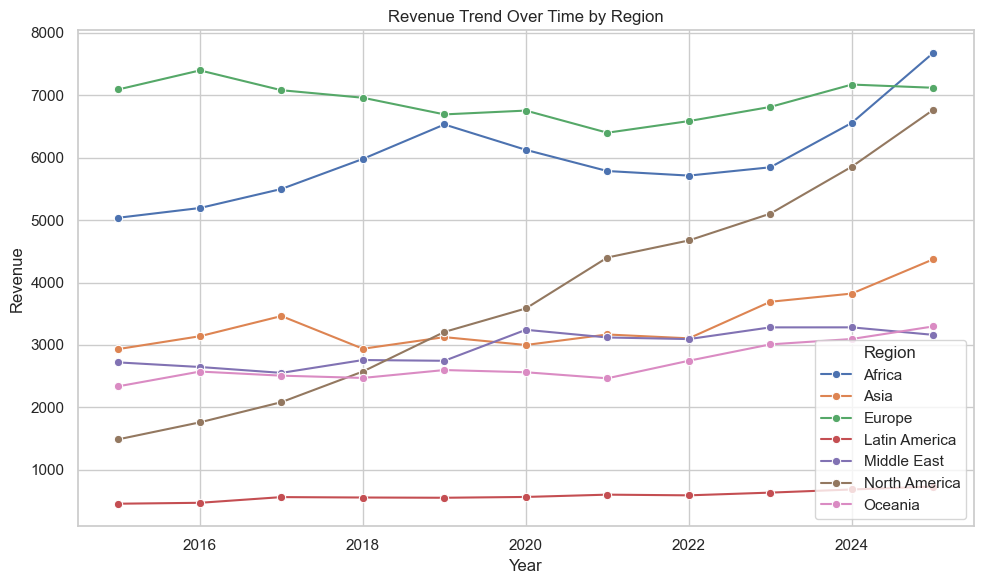

In [45]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=filtered_df,
    x="Year",
    y="Revenue",
    hue="Region",
    marker="o"
)

plt.title("Revenue Trend Over Time by Region")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 1 Explanation
This line chart shows how company revenue changed over time across different regions. The results suggest that revenue trends are not the same in every region. Some regions maintain relatively high revenue levels throughout the period, while others show stronger growth over time. This indicates that regional differences may play an important role in company financial performance.

In [48]:
print(filtered_df.columns.tolist())

['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']


<Axes: xlabel='Year', ylabel='ESG_Overall'>

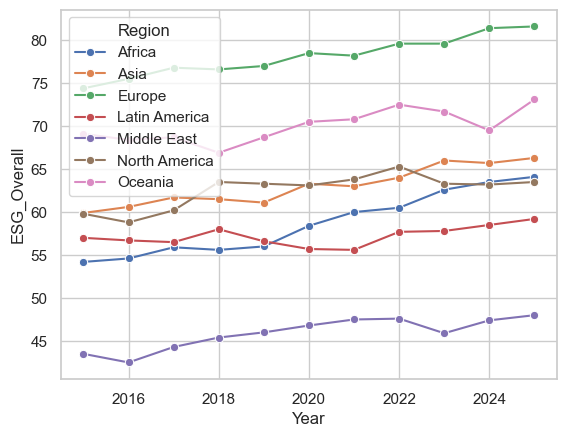

In [49]:
sns.lineplot(
    data=filtered_df,
    x="Year",
    y="ESG_Overall",
    hue="Region",
    marker="o"
)

In [ ]:
### Figure 2 Explanation
This chart presents the trend of overall ESG scores across regions over time. It shows that ESG performance differs by region, and some regions appear to improve more steadily than others. This suggests that companies in different regions may face different sustainability priorities, regulations, or market expectations.

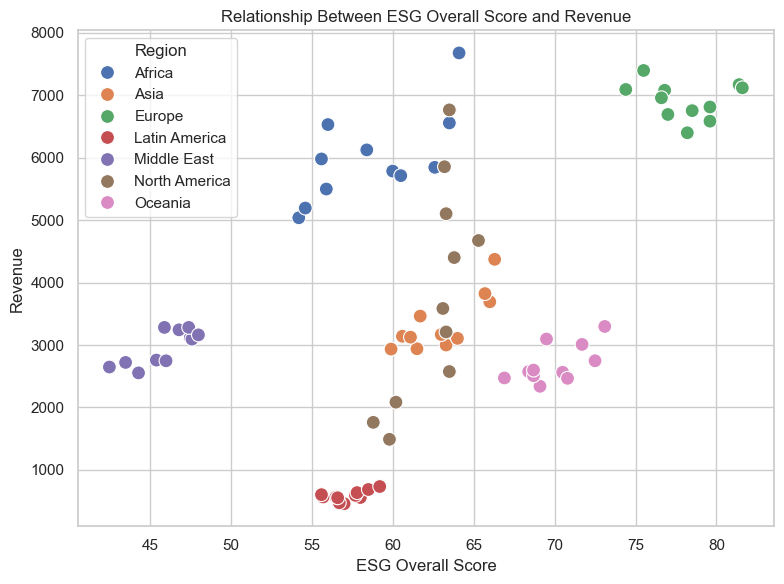

In [51]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=filtered_df,
    x="ESG_Overall",
    y="Revenue",
    hue="Region",
    s=100
)

plt.title("Relationship Between ESG Overall Score and Revenue")
plt.xlabel("ESG Overall Score")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 3 Explanation
This scatter plot explores the relationship between overall ESG score and revenue. The distribution of points suggests that companies with stronger ESG performance may also achieve relatively higher revenue in some cases. However, the relationship is not perfectly consistent across all observations, which means ESG may be an important factor, but not the only factor influencing revenue.

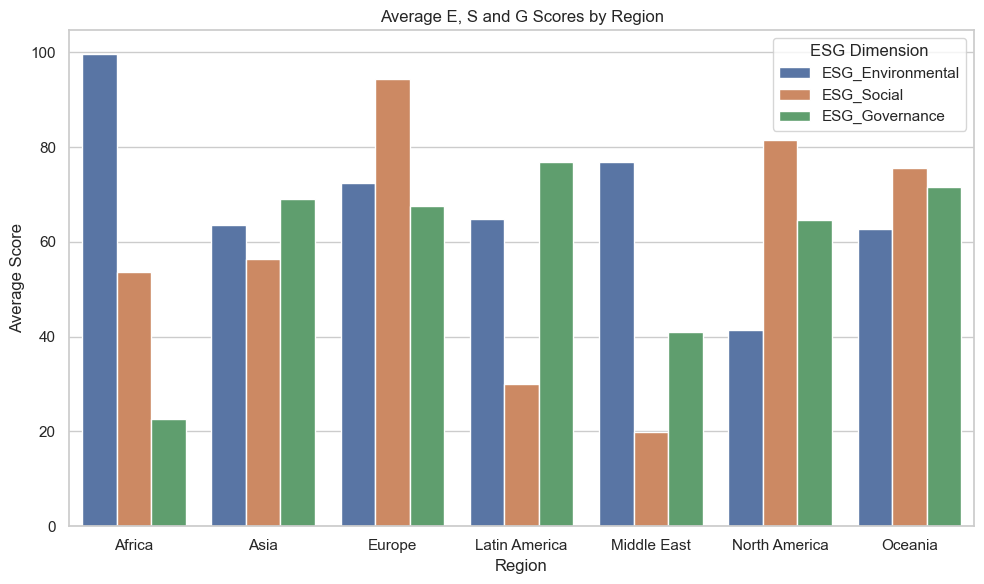

In [54]:
esg_compare = filtered_df.groupby("Region")[["ESG_Environmental", "ESG_Social", "ESG_Governance"]].mean().reset_index()

esg_long = esg_compare.melt(
    id_vars="Region",
    value_vars=["ESG_Environmental", "ESG_Social", "ESG_Governance"],
    var_name="ESG_Dimension",
    value_name="Average_Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=esg_long,
    x="Region",
    y="Average_Score",
    hue="ESG_Dimension"
)

plt.title("Average E, S and G Scores by Region")
plt.xlabel("Region")
plt.ylabel("Average Score")
plt.legend(title="ESG Dimension")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 5 Explanation
This bar chart compares the average Environmental, Social, and Governance scores across regions. It shows that ESG performance is not uniform, and different regions may perform better in different dimensions. This helps explain why overall ESG performance may influence revenue differently across regions.

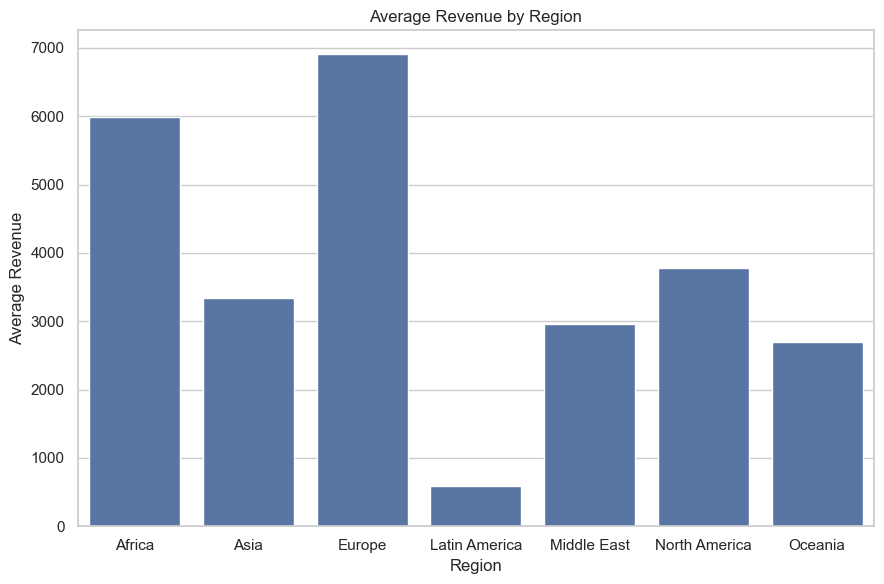

In [55]:
revenue_region = filtered_df.groupby("Region")["Revenue"].mean().reset_index()

plt.figure(figsize=(9, 6))

sns.barplot(
    data=revenue_region,
    x="Region",
    y="Revenue"
)

plt.title("Average Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 6 Explanation
This bar chart compares average revenue across regions. The results show clear regional differences in revenue levels, suggesting that market conditions, company scale, and regional business environments may influence financial outcomes.

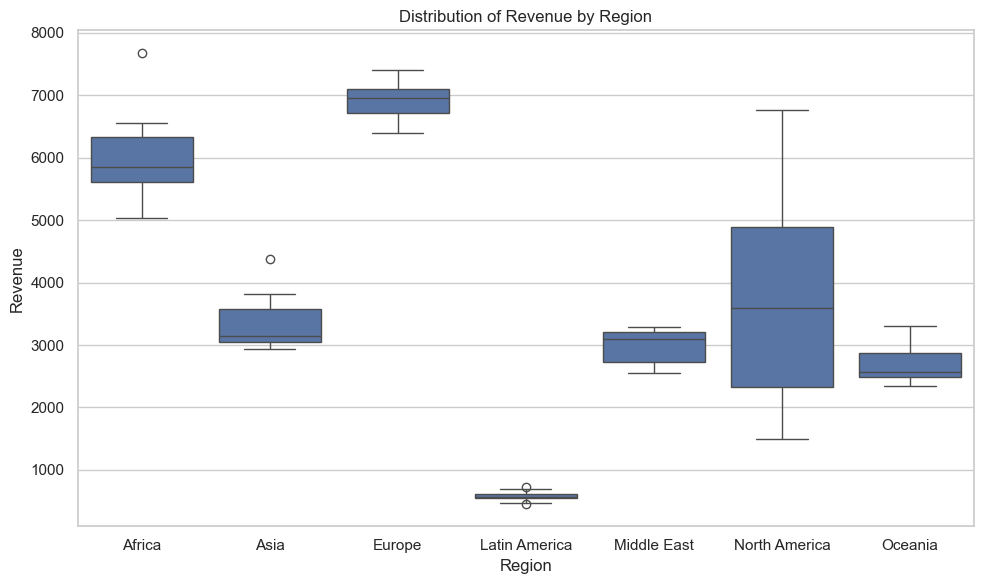

In [56]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=filtered_df,
    x="Region",
    y="Revenue"
)

plt.title("Distribution of Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 7 Explanation
This box plot shows the distribution of revenue in each region. It helps identify differences in median revenue, variation, and possible outliers. The figure suggests that some regions have more stable revenue patterns, while others show greater fluctuation.

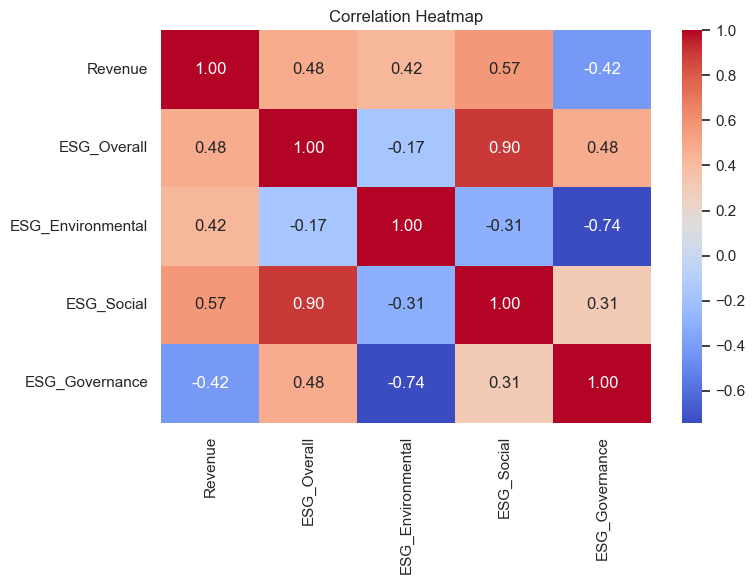

In [58]:
corr_cols = ["Revenue", "ESG_Overall", "ESG_Environmental", "ESG_Social", "ESG_Governance"]
corr_matrix = filtered_df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
### Figure 8 Explanation
This heatmap presents the correlation between revenue and ESG-related indicators. It provides an overall view of how strongly revenue is associated with ESG performance and its individual dimensions. The results help identify which ESG variables may have a closer relationship with financial performance.